In [1]:
from anchoring_detection.preprocess import Preprocess

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn import svm
from sklearn.linear_model import SGDClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

from sklearn.model_selection import cross_val_score
from sklearn.model_selection import cross_val_predict
from sklearn.model_selection import GridSearchCV


import matplotlib.pyplot as plt
from mlxtend.plotting import plot_confusion_matrix

In [2]:
prepro = Preprocess()

Cargamos los datos de las simulaciones

In [3]:
# FUNCIONA
dataframes_surge, dataframes_sway = prepro.extract_res_files()

In [4]:
dataframes_surge['oc4__Hs1__Tp2__dir1__1']

,time[s],Surge
0,180.0,-5.67869
1,180.1,-5.67247
2,180.2,-5.66642
3,180.3,-5.66057
4,180.4,-5.65496
...,...,...
10196,1199.6,-4.24638
10197,1199.7,-4.24186
10198,1199.8,-4.23708
10199,1199.9,-4.23206


In [5]:
dataframes_sway['oc4__Hs1__Tp2__dir1__1']

,time[s],Sway
0,180.0,3.80982
1,180.1,3.80965
2,180.2,3.80952
3,180.3,3.80944
4,180.4,3.80942
...,...,...
10196,1199.6,5.17008
10197,1199.7,5.17448
10198,1199.8,5.17881
10199,1199.9,5.18303


Las señales requieren estabilización en el equilibrio porque se produce ligero hundimiento (por el error cometido en el cálculo manual de Fz de compensación de obra muerta). Con el siguiente método, solventamos este problema y aplicamos fft.

In [6]:
tff = prepro.fourier_python()

In [7]:
dataframes_surge['oc4__Hs2__Tp3__dir1__1']

,Frequencies,Amplitudes
0,0.000000,5.750392e-16
1,0.000980,9.291214e-02
2,0.001961,1.090917e-01
3,0.002941,1.040350e-01
4,0.003921,8.044447e-02
...,...,...
5095,4.994608,4.029734e-05
5096,4.995589,4.028932e-05
5097,4.996569,4.030096e-05
5098,4.997549,4.027051e-05


Determinamos los momentos espectrales de cada simulación

In [8]:
moments = prepro.moment_python()

In [9]:
moments

,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway
oc4__Hs1__Tp2__dir1__1,0.002438,0.003567,0.047892,0.001749,0.003374,0.045315
oc4__Hs1__Tp2__dir1__2,0.011784,0.020603,0.276744,0.008595,0.015042,0.202063
oc4__Hs1__Tp2__dir2__1,0.002250,0.003548,0.047649,0.001852,0.002840,0.038124
oc4__Hs1__Tp2__dir2__2,0.011667,0.020584,0.276506,0.008593,0.014508,0.194887
oc4__Hs1__Tp2__dir3__1,0.002209,0.003746,0.050323,0.001888,0.002869,0.038510
...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,0.012230,0.020804,0.279441,0.018121,0.027863,0.373985
oc4__Hs4__Tp5__dir4__1,0.005428,0.002837,0.037927,0.010878,0.014440,0.193691
oc4__Hs4__Tp5__dir4__2,0.012206,0.014142,0.189936,0.016706,0.025973,0.348638
oc4__Hs4__Tp5__dir5__1,0.011085,0.009327,0.124935,0.002734,0.003005,0.040322


Adjuntamos las etiquetas al dataset

In [10]:
cases = pd.read_csv(r'C:\Users\naval\Desktop\Arturo\Mooring_anomaly_detector\data\labels.csv', sep=';')

labels = cases.iloc[:, :3].set_index(moments.index)
state = cases.iloc[:, 3:].set_index(moments.index)

dataset = pd.concat([labels,moments,state],axis=1)

In [11]:
#dataset = dataset.sample(frac=1)

In [12]:
dataset

,Hs,Tp,Direction,m0_Surge,m2_Surge,m4_Surge,m0_Sway,m2_Sway,m4_Sway,Dragging
oc4__Hs1__Tp2__dir1__1,1.21,8.15,0,0.002438,0.003567,0.047892,0.001749,0.003374,0.045315,0
oc4__Hs1__Tp2__dir1__2,1.21,8.15,0,0.011784,0.020603,0.276744,0.008595,0.015042,0.202063,1
oc4__Hs1__Tp2__dir2__1,1.21,8.15,60,0.002250,0.003548,0.047649,0.001852,0.002840,0.038124,0
oc4__Hs1__Tp2__dir2__2,1.21,8.15,60,0.011667,0.020584,0.276506,0.008593,0.014508,0.194887,1
oc4__Hs1__Tp2__dir3__1,1.21,8.15,90,0.002209,0.003746,0.050323,0.001888,0.002869,0.038510,0
...,...,...,...,...,...,...,...,...,...,...
oc4__Hs4__Tp5__dir3__2,8.10,18.69,90,0.012230,0.020804,0.279441,0.018121,0.027863,0.373985,1
oc4__Hs4__Tp5__dir4__1,8.10,18.69,120,0.005428,0.002837,0.037927,0.010878,0.014440,0.193691,0
oc4__Hs4__Tp5__dir4__2,8.10,18.69,120,0.012206,0.014142,0.189936,0.016706,0.025973,0.348638,1
oc4__Hs4__Tp5__dir5__1,8.10,18.69,180,0.011085,0.009327,0.124935,0.002734,0.003005,0.040322,0


array([[<Axes: title={'center': 'Hs'}>, <Axes: title={'center': 'Tp'}>,
        <Axes: title={'center': 'Direction'}>],
       [<Axes: title={'center': 'm0_Surge'}>,
        <Axes: title={'center': 'm2_Surge'}>,
        <Axes: title={'center': 'm4_Surge'}>],
       [<Axes: title={'center': 'm0_Sway'}>,
        <Axes: title={'center': 'm2_Sway'}>,
        <Axes: title={'center': 'm4_Sway'}>],
       [<Axes: title={'center': 'Dragging'}>, <Axes: >, <Axes: >]],
      dtype=object)

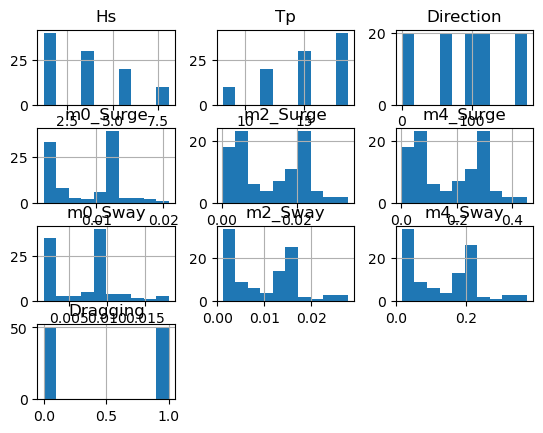

In [13]:
dataset.hist()

<Axes: >

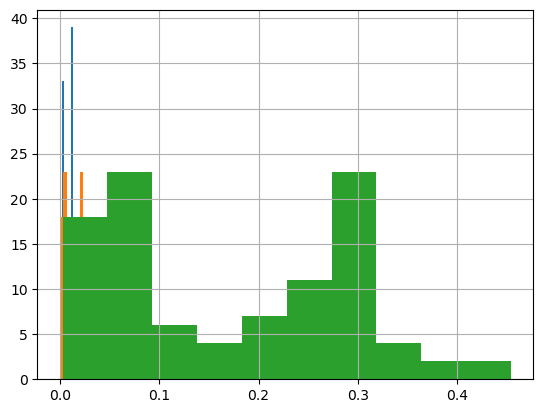

In [14]:
dataset['m0_Surge'].hist()
dataset['m2_Surge'].hist()
dataset['m4_Surge'].hist()

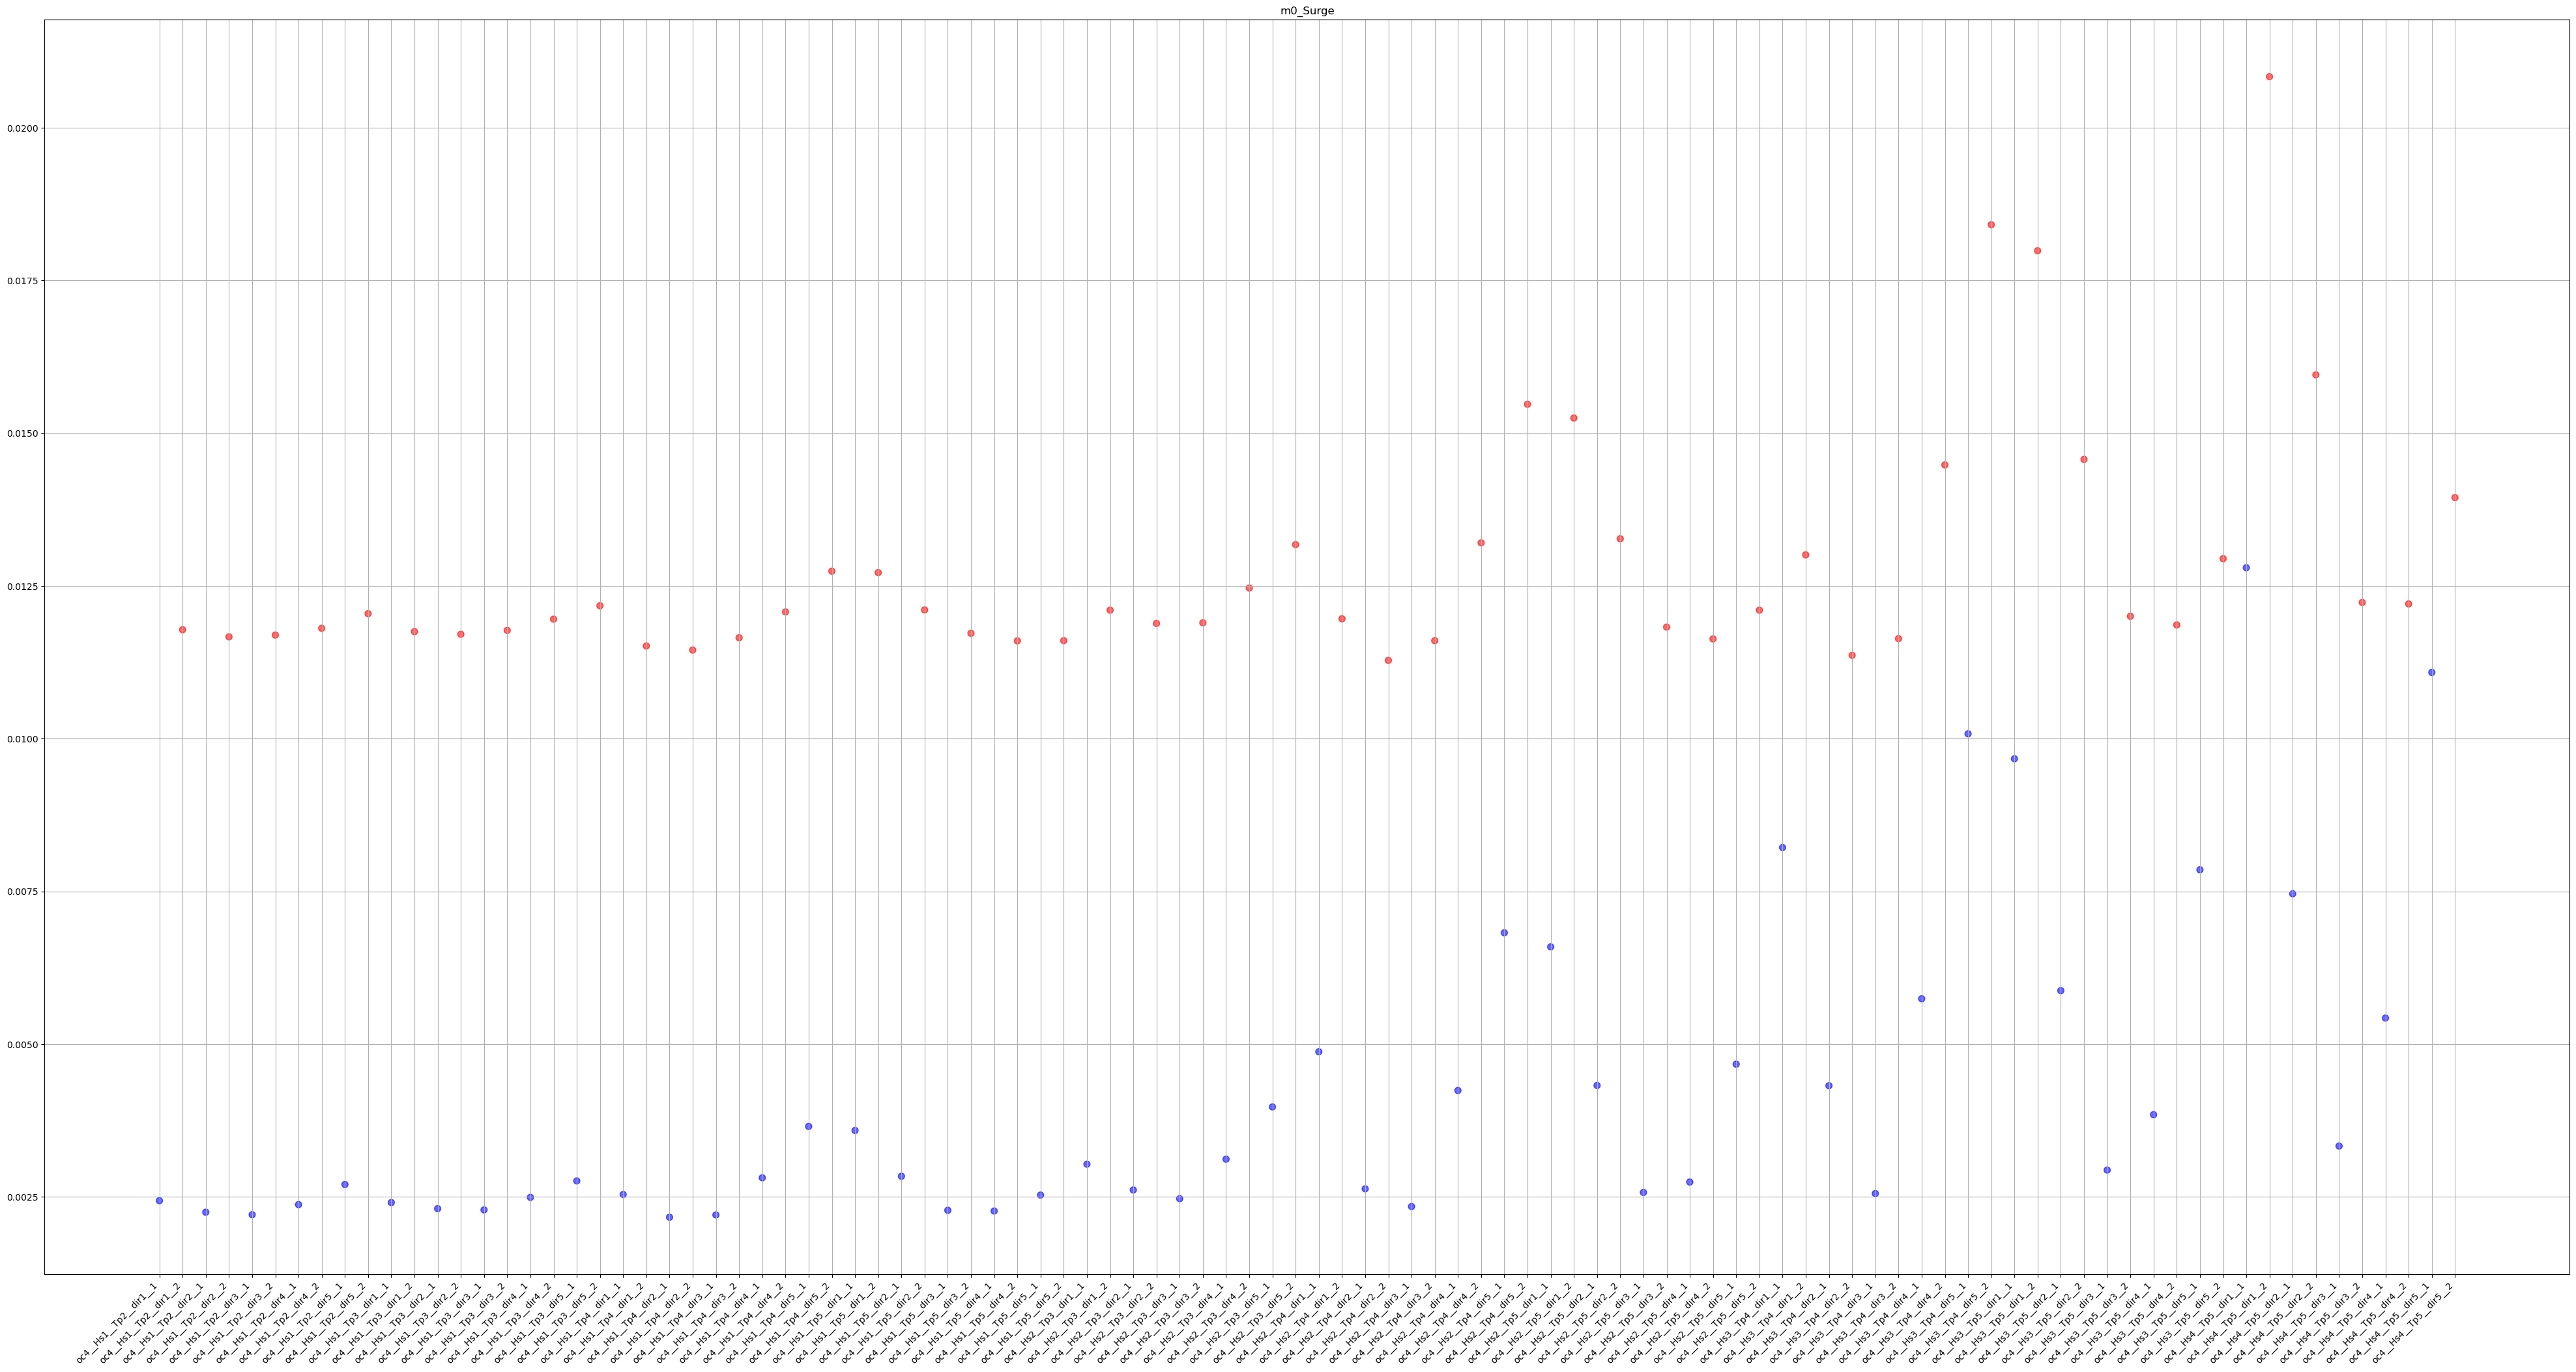

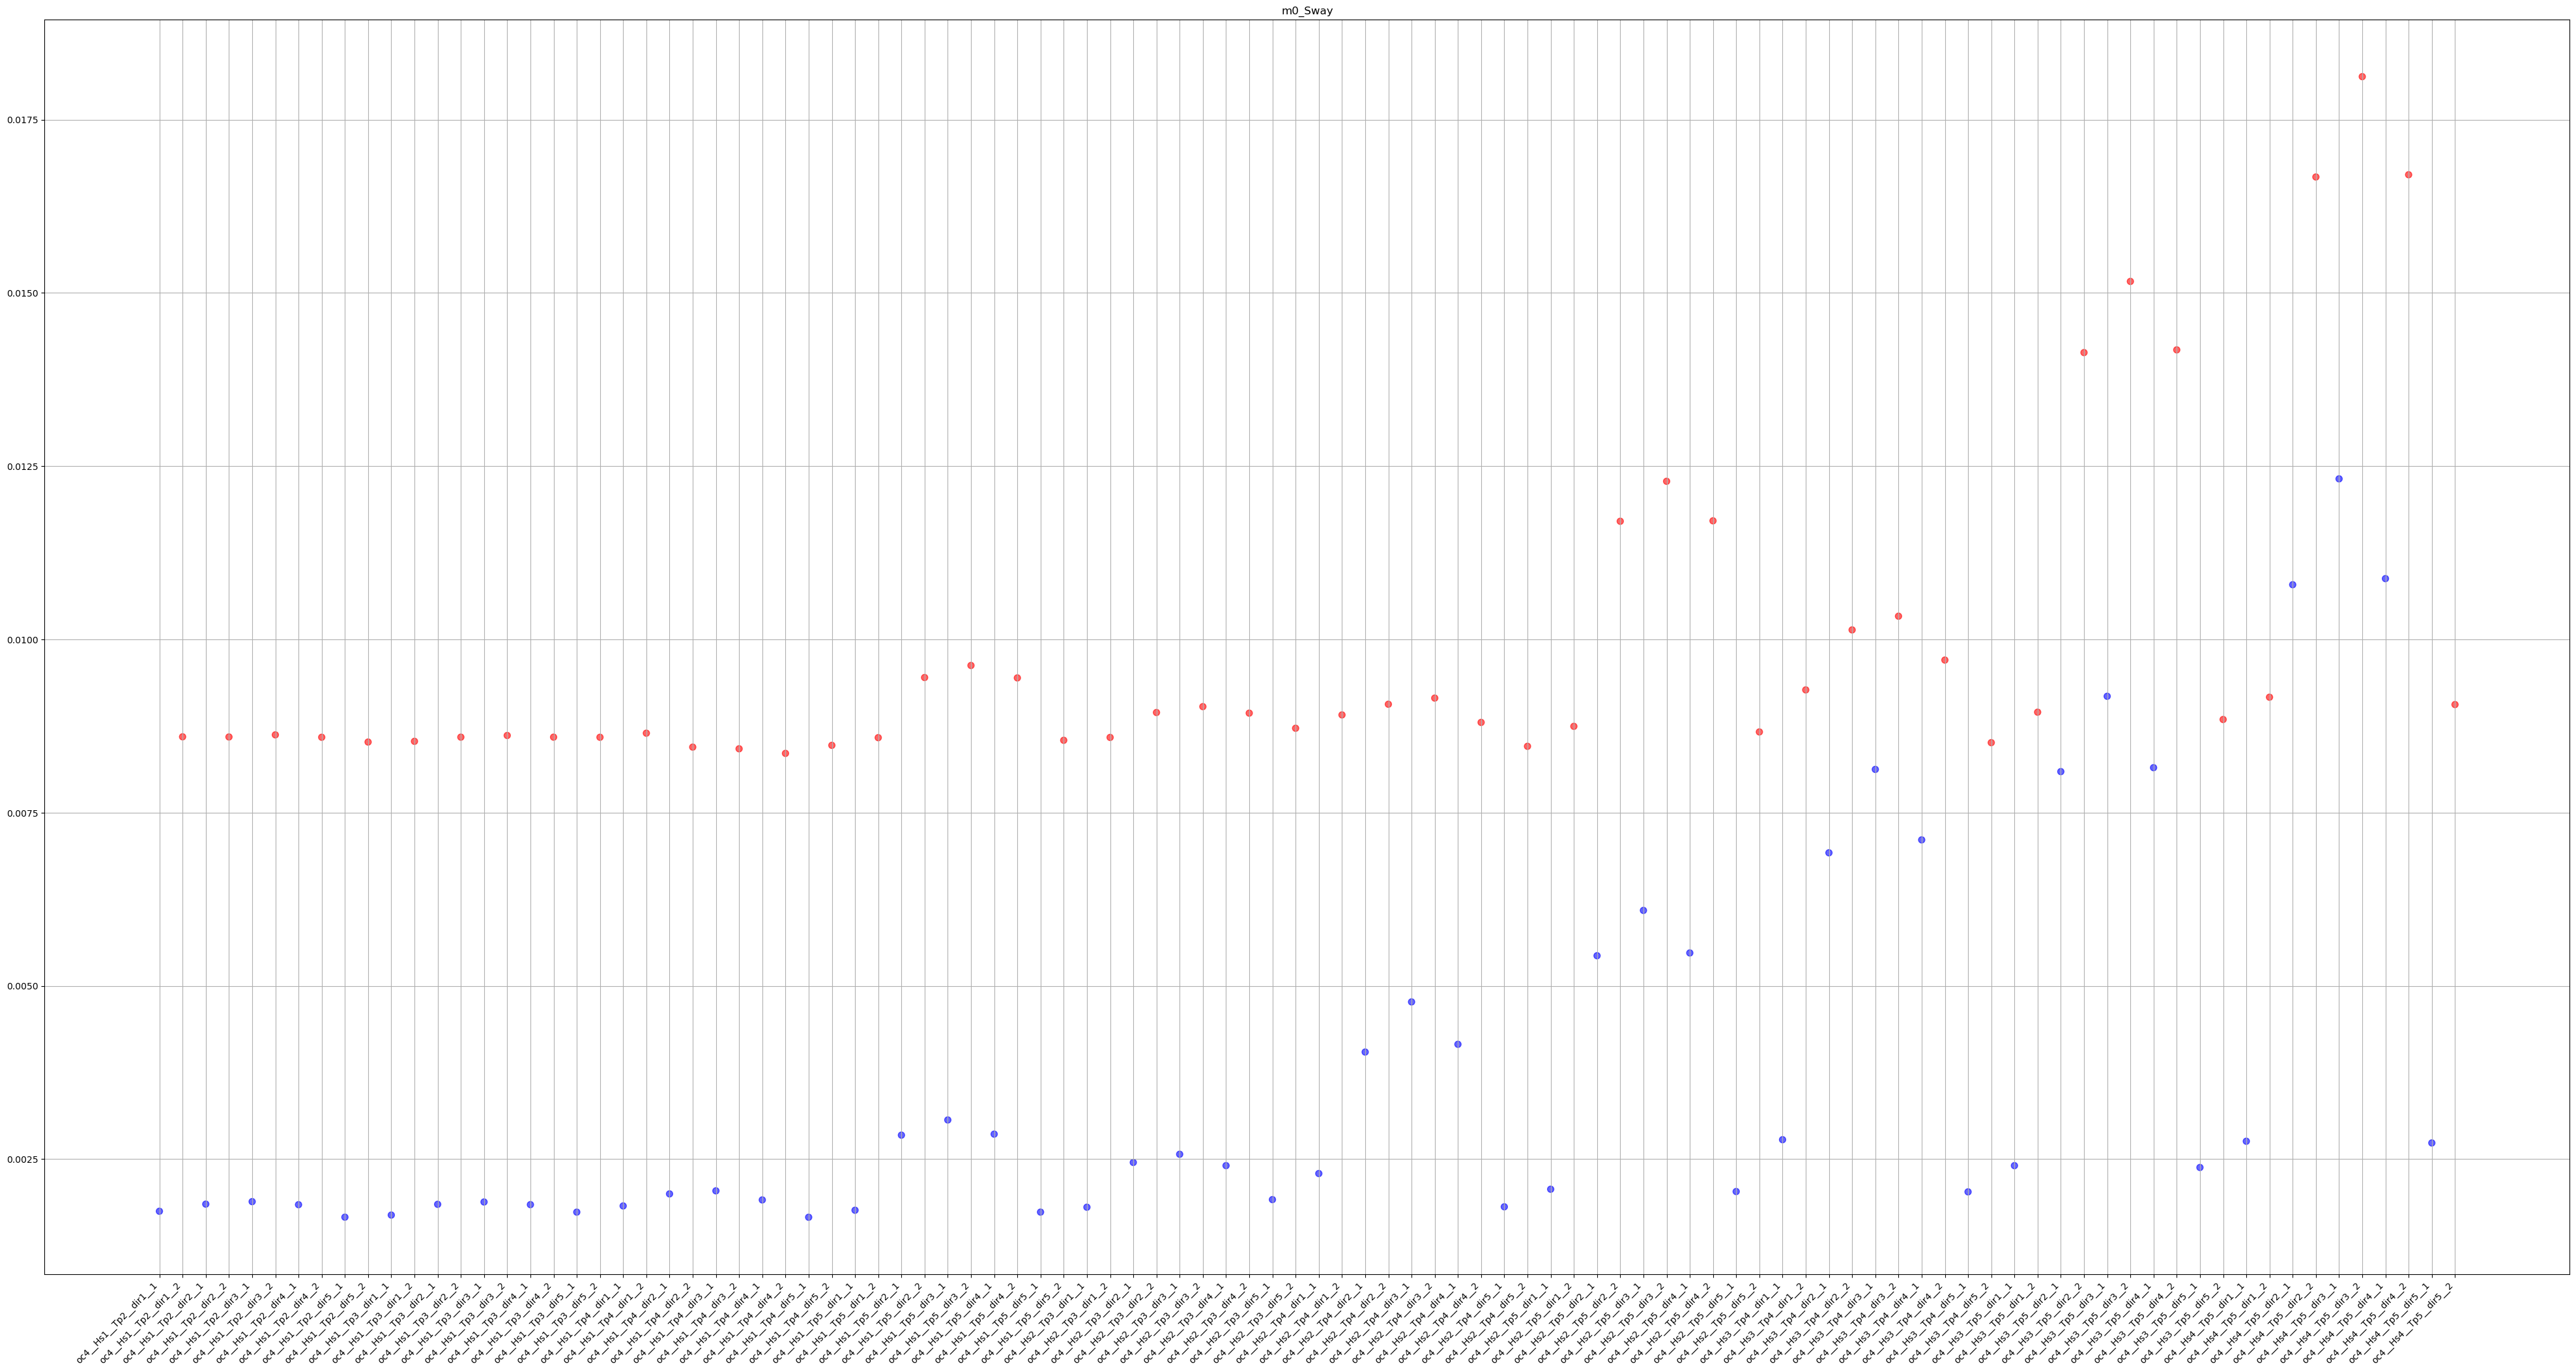

In [15]:
moves = ['Surge','Sway']
for mov in moves:
    plt.figure(figsize=(50,25))
    colors = dataset['Dragging'].map({1: 'r', 0: 'b'})
    plt.scatter(dataset.index,dataset[f'm0_{mov}'],color=colors, alpha=0.6, s=50)
    plt.xticks(rotation=45,ha='right')
    plt.title(f"m0_{mov}")
    plt.grid()

Se requiere dividir los dataframes en datos de train y test, ademas de escalar y normalizar los momentos

In [122]:
#X = dataset[['m0_Surge', 'm2_Surge', 'm4_Surge', 'm0_Sway', 'm2_Sway', 'm4_Sway']]
X = dataset[['m0_Surge','m0_Sway']]
Y = dataset['Dragging']

In [123]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [124]:
X_train

,m0_Surge,m0_Sway
oc4__Hs2__Tp4__dir3__2,0.011605,0.009154
oc4__Hs3__Tp5__dir5__1,0.007855,0.002380
oc4__Hs1__Tp4__dir4__1,0.002813,0.001912
oc4__Hs2__Tp3__dir2__1,0.002614,0.002453
oc4__Hs2__Tp5__dir5__2,0.012104,0.008665
...,...,...
oc4__Hs2__Tp5__dir1__1,0.006594,0.002067
oc4__Hs3__Tp4__dir1__2,0.013009,0.009272
oc4__Hs1__Tp3__dir3__1,0.002287,0.001882
oc4__Hs4__Tp5__dir2__1,0.007462,0.010790


In [125]:
min_max_scaler = MinMaxScaler()
X_train_min_max = min_max_scaler.fit_transform(X_train)
X_test_min_max = min_max_scaler.transform(X_test)

In [126]:
X_train_min_max

array([[5.04500640e-01, 4.55158355e-01],
       [3.03228249e-01, 4.36359741e-02],
       [3.26131792e-02, 1.51920119e-02],
       [2.19380042e-02, 4.80576861e-02],
       [5.31270921e-01, 4.25489346e-01],
       [5.13528602e-01, 4.22374363e-01],
       [4.45846522e-02, 8.79549088e-03],
       [1.72981673e-01, 5.59902401e-01],
       [5.28233938e-01, 4.16633467e-01],
       [1.13535170e-01, 3.19524879e-01],
       [5.12448098e-01, 4.17256043e-01],
       [5.50741447e-01, 4.41963946e-01],
       [5.25921438e-01, 8.20456289e-01],
       [7.77665957e-02, 0.00000000e+00],
       [7.37998488e-01, 9.12025038e-01],
       [5.09386073e-01, 4.22926047e-01],
       [2.89048100e-02, 2.31721707e-01],
       [5.16402185e-01, 6.45224692e-01],
       [5.10958037e-01, 4.83749688e-01],
       [1.54215944e-02, 1.10629605e-02],
       [5.88874676e-01, 4.28713567e-01],
       [4.04885713e-03, 8.52896157e-02],
       [5.15357644e-01, 4.20816377e-01],
       [5.38037737e-01, 1.00000000e+00],
       [5.297561

In [127]:
X_test_min_max

array([[ 6.63733468e-01,  7.58073966e-01],
       [ 4.87173885e-01,  4.49767435e-01],
       [ 3.22760367e-01,  6.79966552e-02],
       [ 5.20230823e-01,  4.47677483e-01],
       [ 1.42889728e-02,  5.52338829e-02],
       [ 5.04519910e-01,  4.18150844e-01],
       [-2.04055519e-03,  2.04837467e-02],
       [ 4.00758713e-01,  4.52471499e-02],
       [ 1.08575442e-02,  1.91338564e-03],
       [ 1.25044611e-02,  5.26385283e-03],
       [ 2.98893951e-02,  4.48592072e-03],
       [ 7.41840630e-02,  6.14907855e-03],
       [ 4.91613222e-01,  5.14942585e-01],
       [ 5.31501789e-01,  4.73184436e-01],
       [ 5.68578939e-01,  6.66354396e-02],
       [ 1.97387503e-04,  1.37018451e-02],
       [ 1.89916167e-01,  3.30847001e-01],
       [ 6.58873309e-01,  4.88498490e-01],
       [ 5.53890124e-03,  1.13371423e-02],
       [ 5.64287453e-01,  4.20466626e-01]])

## Modelos

### SGD

In [22]:
sgd_clf = SGDClassifier()

In [23]:
sgd_clf.fit(X_train_min_max,Y_train)

SGDClassifier()

In [24]:
cross_val_score(sgd_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([1.    , 1.    , 0.9375, 1.    , 1.    ])

In [25]:
Y_pred_sgd = cross_val_predict(sgd_clf, X_train_min_max, Y_train, cv=5)

In [26]:
Y_pred_sgd

array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1], dtype=int64)

In [27]:
Y_pred_sgd = sgd_clf.predict(X_test_min_max)

Métricas

In [28]:
rmse_sgd = np.sqrt(metrics.mean_squared_error(Y_train, Y_pred_sgd))
acu_sgd = metrics.accuracy_score(Y_train,Y_pred_sgd)
precision_sgd = metrics.precision_score(Y_train,Y_pred_sgd)
recall_sgd = metrics.recall_score(Y_train,Y_pred_sgd)
f1_sgd = metrics.f1_score(Y_train,Y_pred_sgd)

print(f"% ERROR --> {rmse_sgd*100} %")
print(f"% ACURACCY --> {acu_sgd*100} %")
print(f"% PRECISION --> {precision_sgd*100} %")
print(f"% RECALL --> {recall_sgd*100} %")
print(f"% f1 --> {f1_sgd*100} %")

ValueError: Found input variables with inconsistent numbers of samples: [80, 20]

matriz de confusión

In [ ]:
cm = metrics.confusion_matrix(Y_train,Y_pred_sgd)
cm

array([[37,  1],
       [ 0, 42]], dtype=int64)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

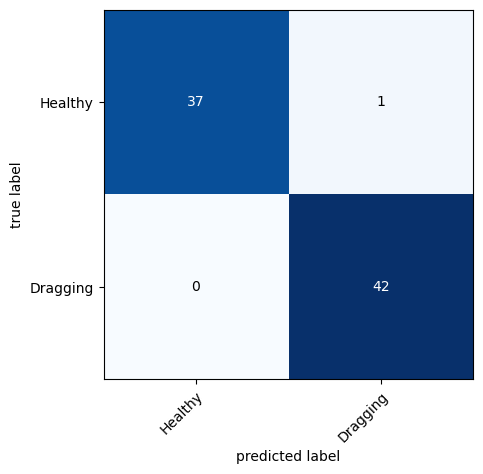

In [ ]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm,class_names=dragging)

In [ ]:
print(Y_train)
print(Y_pred_sgd)

oc4__Hs2__Tp4__dir3__2    1
oc4__Hs3__Tp5__dir5__1    0
oc4__Hs1__Tp4__dir4__1    0
oc4__Hs2__Tp3__dir2__1    0
oc4__Hs2__Tp5__dir5__2    1
                         ..
oc4__Hs2__Tp5__dir1__1    0
oc4__Hs3__Tp4__dir1__2    1
oc4__Hs1__Tp3__dir3__1    0
oc4__Hs4__Tp5__dir2__1    0
oc4__Hs2__Tp4__dir1__2    1
Name: Dragging, Length: 80, dtype: int64
[1 0 0 0 1 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 1 0 1 1 1 1 1 1 0 1 0 1 1 0 0 0 0
 0 0 1 0 1 0 1 0 1 0 0 1 1 1 1 0 0 1 1 1 0 0 1 1 0 1 1 1 0 1 0 1 1 1 0 0 0
 0 0 1 0 0 1]


### SVM

In [128]:
svm_clf = svm.SVC()

In [129]:
svm_clf.fit(X_train_min_max,Y_train)

SVC()

Validación cruzada del entrenamiento

In [130]:
cross_val_score(svm_clf, X_train_min_max, Y_train, cv=5,scoring='accuracy')

array([1., 1., 1., 1., 1.])

In [131]:
y_validate_pred = cross_val_predict(svm_clf, X_train_min_max, Y_train, cv=5)
y_validate_pred

array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

In [132]:
acu_svc = metrics.accuracy_score(Y_train,y_validate_pred)
precision_svc = metrics.precision_score(Y_train,y_validate_pred)
recall_svc = metrics.recall_score(Y_train,y_validate_pred)
f1_svc = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_svc*100} %")
print(f"% PRECISION --> {precision_svc*100} %")
print(f"% RECALL --> {recall_svc*100} %")
print(f"% f1 --> {f1_svc*100} %")

% ACURACCY --> 100.0 %
% PRECISION --> 100.0 %
% RECALL --> 100.0 %
% f1 --> 100.0 %


In [133]:
cm_svc = metrics.confusion_matrix(Y_train,y_validate_pred)
cm_svc

array([[38,  0],
       [ 0, 42]], dtype=int64)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

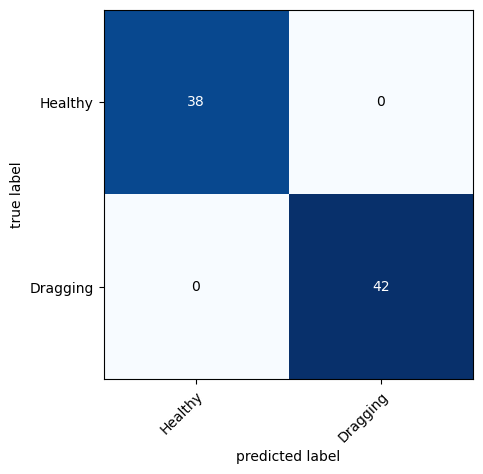

In [134]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc,class_names=dragging)

In [135]:
y_pred = svm_clf.predict(X_test_min_max)

In [136]:
cm_svc_test = metrics.confusion_matrix(Y_test,y_pred)
cm_svc_test

array([[12,  0],
       [ 0,  8]], dtype=int64)

(<Figure size 640x480 with 1 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

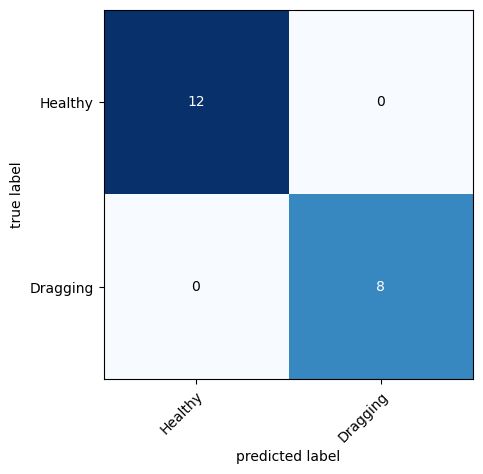

In [137]:
dragging = ['Healthy','Dragging']

plot_confusion_matrix(conf_mat=cm_svc_test,class_names=dragging)

In [143]:
medias_por_vector = np.mean(X_train_min_max, axis=1)

Text(0.5, 1.0, 'Compare train status with m0 mean')

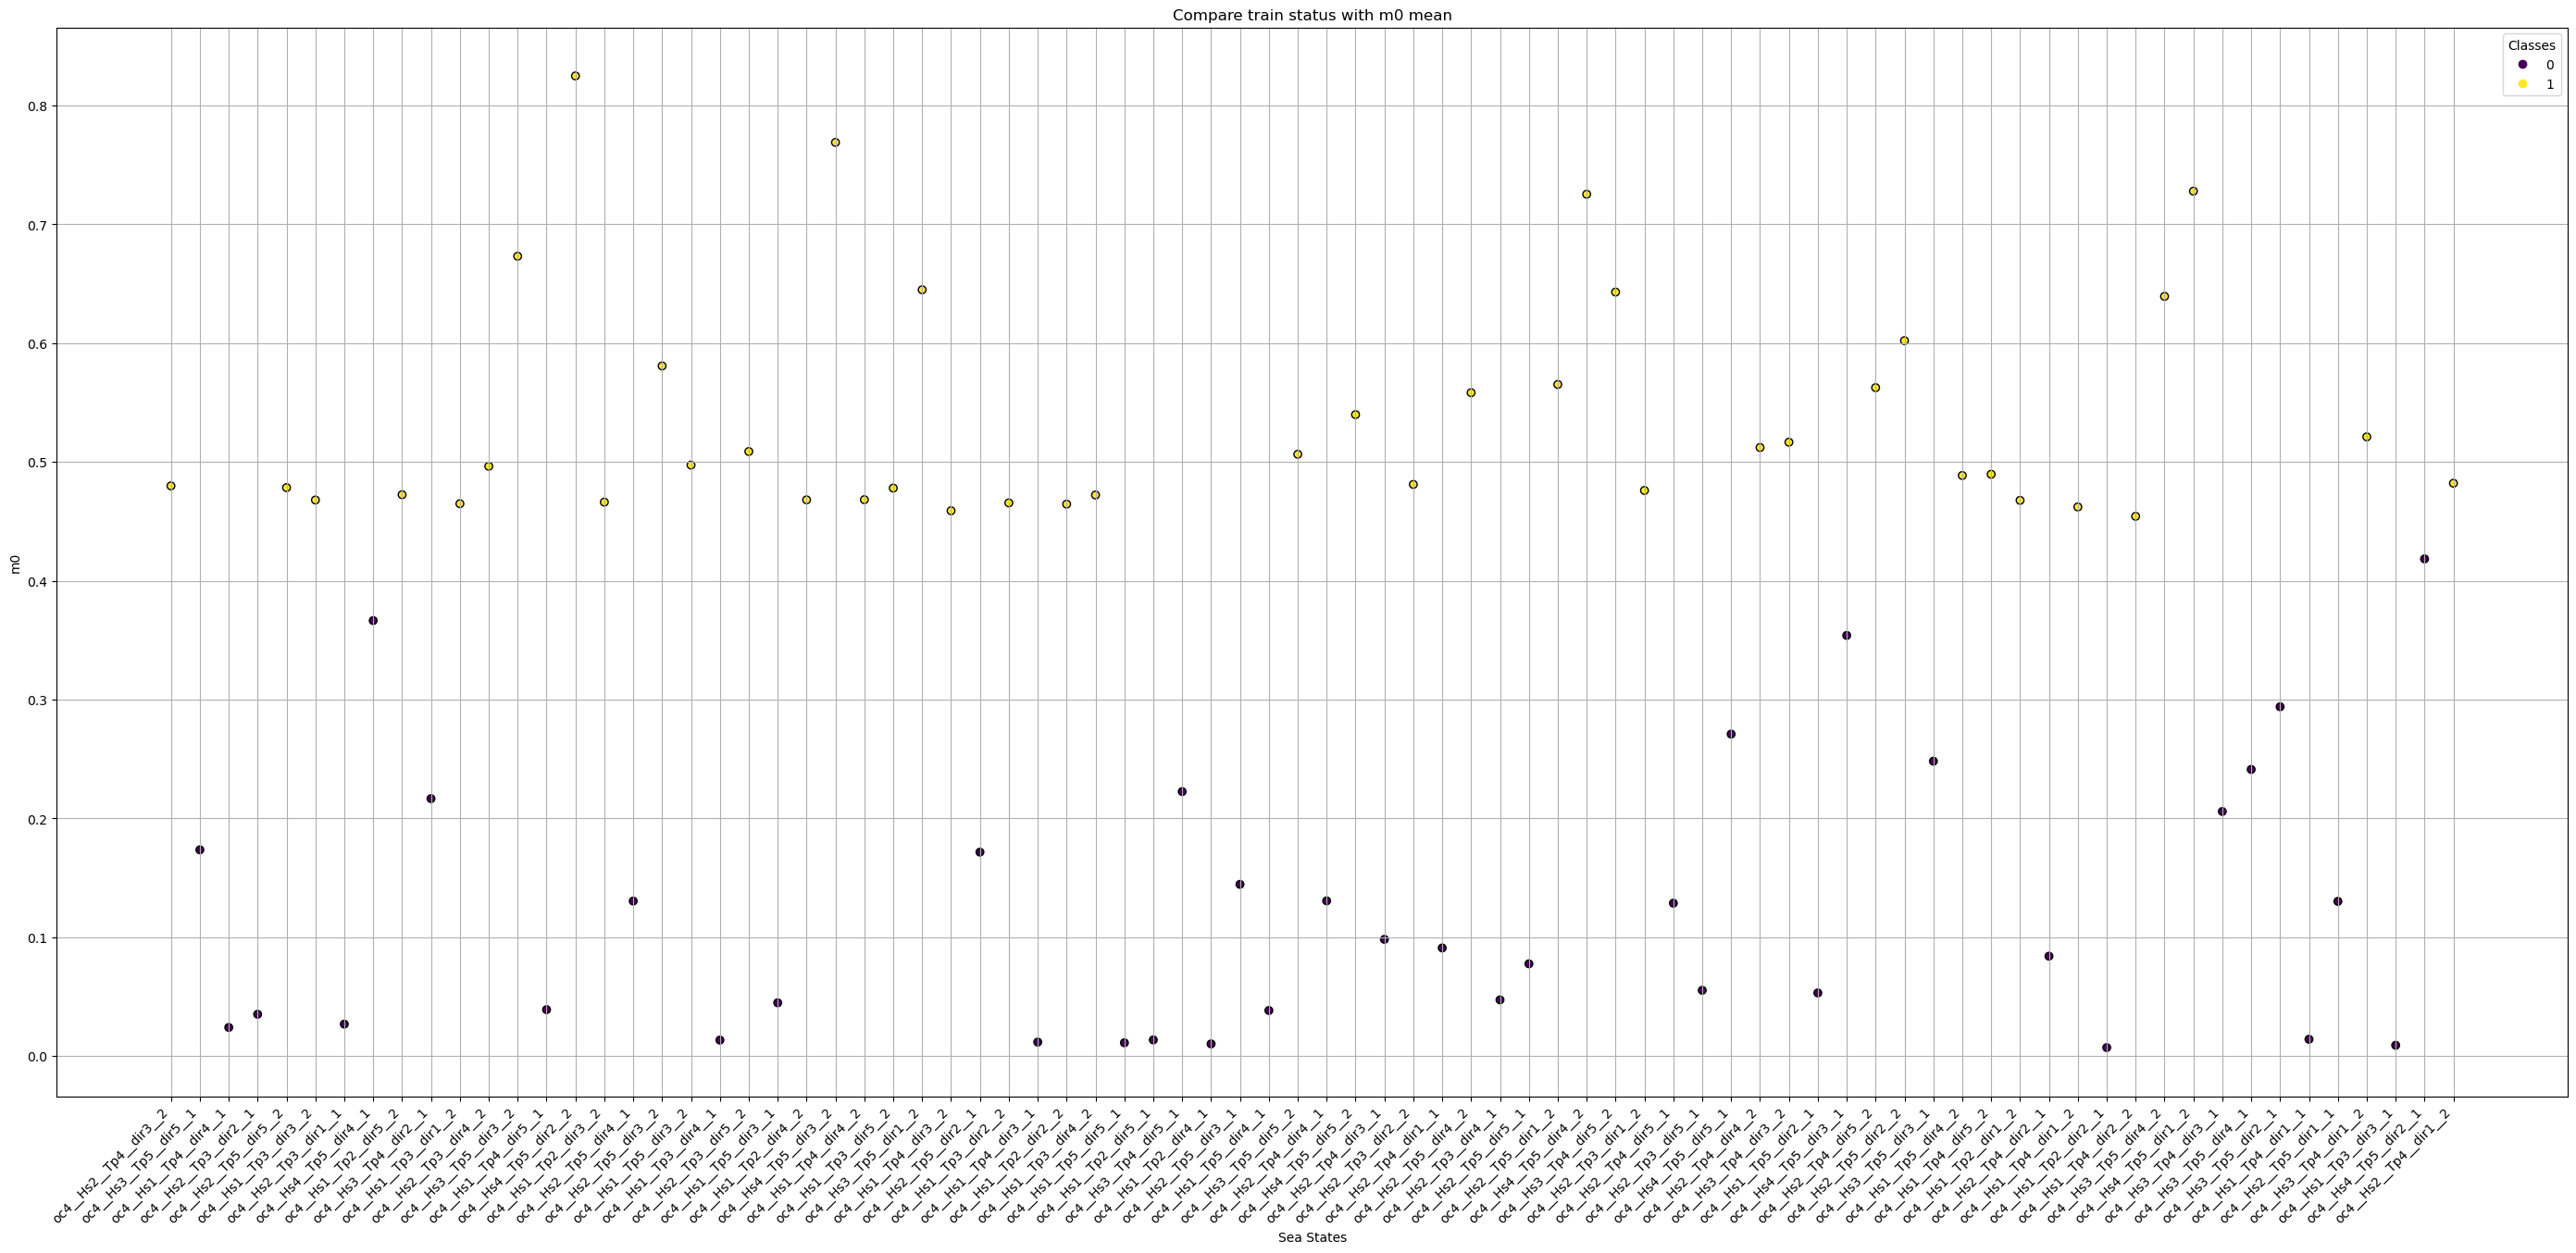

In [147]:
plt.figure(figsize=(35,15))
scat0 = plt.scatter(Y_train.index,medias_por_vector,c=Y_train, label=Y_train, edgecolors="k")
plt.xlabel('Sea States')
plt.ylabel('m0')
plt.grid()
plt.xticks(rotation=45,ha='right')
plt.legend(*scat0.legend_elements(),loc="upper right", title="Classes")
plt.title("Compare train status with m0 mean")

Vamos a ajustar hiperparametros

In [77]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'C':[1, 10, 100, 1000],'kernel':['linear']},
    {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['rbf']},
    {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001], 'kernel': ['sigmoid']}
]

grid_search = GridSearchCV(svm_clf, param_grid, cv=10, scoring='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=10, estimator=SVC(C=100, gamma=0.001),
             param_grid=[{'C': [1, 10, 100, 1000], 'kernel': ['linear']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['rbf']},
                         {'C': [1, 10, 100, 1000], 'gamma': [0.001, 0.0001],
                          'kernel': ['sigmoid']}],
             return_train_score=True, scoring='accuracy')

In [78]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_train_score"], cvres["params"]):
    print(mean_score, params)

0.9694444444444444 {'C': 1, 'kernel': 'linear'}
0.9902777777777778 {'C': 10, 'kernel': 'linear'}
1.0 {'C': 100, 'kernel': 'linear'}
1.0 {'C': 1000, 'kernel': 'linear'}
0.525 {'C': 1, 'gamma': 0.001, 'kernel': 'rbf'}
0.525 {'C': 1, 'gamma': 0.0001, 'kernel': 'rbf'}
0.525 {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
0.525 {'C': 10, 'gamma': 0.0001, 'kernel': 'rbf'}
0.9597222222222221 {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
0.525 {'C': 100, 'gamma': 0.0001, 'kernel': 'rbf'}
0.9749999999999999 {'C': 1000, 'gamma': 0.001, 'kernel': 'rbf'}
0.9597222222222221 {'C': 1000, 'gamma': 0.0001, 'kernel': 'rbf'}
0.525 {'C': 1, 'gamma': 0.001, 'kernel': 'sigmoid'}
0.525 {'C': 1, 'gamma': 0.0001, 'kernel': 'sigmoid'}
0.525 {'C': 10, 'gamma': 0.001, 'kernel': 'sigmoid'}
0.525 {'C': 10, 'gamma': 0.0001, 'kernel': 'sigmoid'}
0.9666666666666666 {'C': 100, 'gamma': 0.001, 'kernel': 'sigmoid'}
0.525 {'C': 100, 'gamma': 0.0001, 'kernel': 'sigmoid'}
0.9694444444444444 {'C': 1000, 'gamma': 0.001, 'kernel': 's

In [ ]:
print(f'BEST ESTIMATOR --> {grid_search.best_params_}')

BEST ESTIMATOR --> {'C': 100, 'kernel': 'linear'}


### Logistic regresion

In [45]:
log_clf = LogisticRegression()

In [46]:
log_clf.fit(X_train_min_max,Y_train)

LogisticRegression()

In [60]:
cross_val_score(log_clf, X_train_min_max, Y_train, cv=10,scoring='accuracy')

array([1.   , 0.875, 1.   , 1.   , 1.   , 1.   , 0.875, 1.   , 1.   ,
       0.875])

In [51]:
y_validate_pred = cross_val_predict(svm_clf, X_train_min_max, Y_train, cv=5)
y_validate_pred

array([1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1], dtype=int64)

In [52]:
acu_log = metrics.accuracy_score(Y_train,y_validate_pred)
precision_log = metrics.precision_score(Y_train,y_validate_pred)
recall_log = metrics.recall_score(Y_train,y_validate_pred)
f1_log = metrics.f1_score(Y_train,y_validate_pred)

print(f"% ACURACCY --> {acu_log*100} %")
print(f"% PRECISION --> {precision_log*100} %")
print(f"% RECALL --> {recall_log*100} %")
print(f"% f1 --> {f1_log*100} %")

% ACURACCY --> 100.0 %
% PRECISION --> 100.0 %
% RECALL --> 100.0 %
% f1 --> 100.0 %


In [58]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {'C':[1, 10, 50, 100],'penalty':['l1','l2'],'solver':['liblinear']}
    ]

grid_search = GridSearchCV(log_clf, param_grid, cv=10, scoring='accuracy', return_train_score=True)

grid_search.fit(X_train_min_max,Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid=[{'C': [1, 10, 50, 100], 'penalty': ['l1', 'l2'],
                          'solver': ['liblinear']}],
             return_train_score=True, scoring='accuracy')

In [59]:
cvres_log = grid_search.cv_results_
for mean_score, params in zip(cvres_log["mean_train_score"], cvres_log["params"]):
    print(mean_score, params)

0.9708333333333334 {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
0.961111111111111 {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}
1.0 {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
0.9763888888888888 {'C': 10, 'penalty': 'l2', 'solver': 'liblinear'}
1.0 {'C': 50, 'penalty': 'l1', 'solver': 'liblinear'}
0.9888888888888889 {'C': 50, 'penalty': 'l2', 'solver': 'liblinear'}
1.0 {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
0.9986111111111111 {'C': 100, 'penalty': 'l2', 'solver': 'liblinear'}


In [57]:
print(f'BEST ESTIMATOR --> {grid_search.best_params_}')

BEST ESTIMATOR --> {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
